In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

## **Part I -** Get & Preprocess Data

#### LOBSTER Data

We take real high frequency quotes from LOBSTER dataset for MSFT prices on the 2012-06-21 day.

In [8]:
# Data Import
columns_ob = ['Ask','AskVolume','Bid','BidVolume']
df_ob = pd.read_csv('AMZN_2012-06-21_34200000_57600000_orderbook_1.csv',header=None,sep=';')
df_ob.columns = columns_ob

df_desc = pd.read_csv('AMZN_2012-06-21_34200000_57600000_message_1.csv',header=None)
df_desc.columns = ['Time','Type','OrderID','Size','Price','Direction']

raw_data = pd.concat([df_ob,df_desc],axis=1)
raw_data.head()

,Ask,AskVolume,Bid,BidVolume,Time,Type,OrderID,Size,Price,Direction
0,2239500,100,2231800,100,34200.017460,5,0,1,2238200,-1
1,2239500,100,2238100,21,34200.189608,1,11885113,21,2238100,1
2,2239500,100,2237500,100,34200.190226,4,11885113,21,2238100,1
3,2239500,100,2237500,74,34200.190226,4,11534792,26,2237500,1
4,2239500,100,2237500,74,34200.372780,5,0,100,2238400,-1


In [9]:
# Processing
data = ( 
    raw_data.copy()
    .assign(Ask=lambda df : df['Ask']/10000)
    .assign(Bid=lambda df : df['Bid']/10000)
    .assign(Price=lambda df : df['Price']/10000)
    .assign(mid=lambda df : (df['Ask']+df['Bid'])/2)
    .assign(logprice=lambda df : np.log(df['mid']))    
    .assign(logret=lambda df : df['logprice'].diff())    
    .assign(spread=lambda df : df['Ask']-df['Bid'])
    .assign(volumespread=lambda df : df['AskVolume']-df['BidVolume'])
)    

## **Part II -** Exploratory Analysis

Variable descriptions:
- Bid, Ask,
- Prices (=mid price at first approx), log prices
- log returns : comparison with normal distribution
- Volume, BidVolume & AskVolume


In [10]:
data[['Ask', 'AskVolume', 'Bid', 'BidVolume', 'Time', 'Size', 'Price', 'logprice', 'logret']].describe()

,Ask,AskVolume,Bid,BidVolume,Time,Size,Price,logprice,logret
count,57515.000000,57515.000000,57515.000000,57515.000000,57515.000000,57515.000000,57515.000000,57515.000000,5.751400e+04
mean,222.763102,145.363366,222.627194,204.636738,46043.188842,89.517274,222.697948,5.405785,-2.341069e-07
std,1.366422,222.814593,1.348410,329.674751,7394.693092,297.909696,1.357657,0.006093,7.114298e-05
min,220.530000,1.000000,220.510000,1.000000,34200.017460,1.000000,220.510000,5.395988,-1.472196e-03
25%,221.330000,29.000000,221.220000,100.000000,39125.893894,16.000000,221.300000,5.399429,0.000000e+00
50%,222.690000,100.000000,222.570000,100.000000,45690.068894,100.000000,222.630000,5.405489,0.000000e+00
75%,223.930000,200.000000,223.750000,200.000000,53219.768538,100.000000,223.850000,5.410954,0.000000e+00
max,226.040000,5700.000000,226.020000,4404.000000,57599.959360,33570.000000,226.030000,5.420646,1.472196e-03


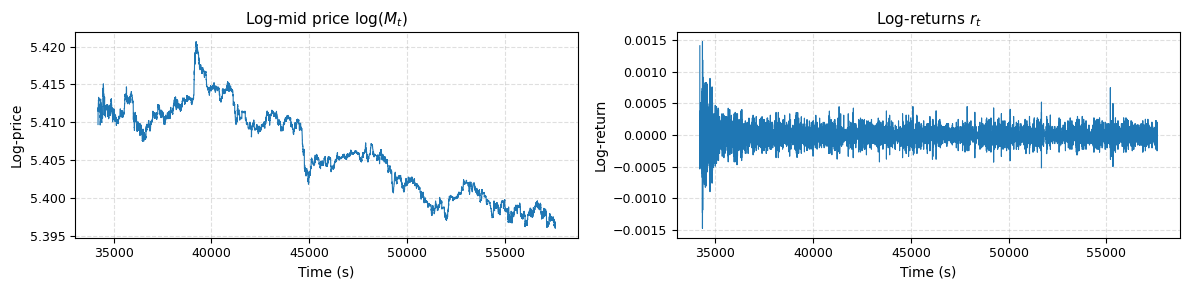

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=True)

# --- Log-price ---
axes[0].plot(
    data["Time"],
    data["logprice"],
    linewidth=0.8
)
axes[0].set_title(r"Log-mid price $\log(M_t)$", fontsize=11)
axes[0].set_ylabel("Log-price")
axes[0].grid(True, linestyle="--", alpha=0.4)

# --- Log-returns ---
axes[1].plot(
    data["Time"],
    data["logret"],
    linewidth=0.8
)
axes[1].set_title(r"Log-returns $r_t$", fontsize=11)
axes[1].set_ylabel("Log-return")
axes[1].grid(True, linestyle="--", alpha=0.4)

# Shared x-axis
for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
#plt.show()

plt.savefig(
    "logprice_logreturns_amzn_20120621.png",
    dpi=300,
    bbox_inches="tight"
)

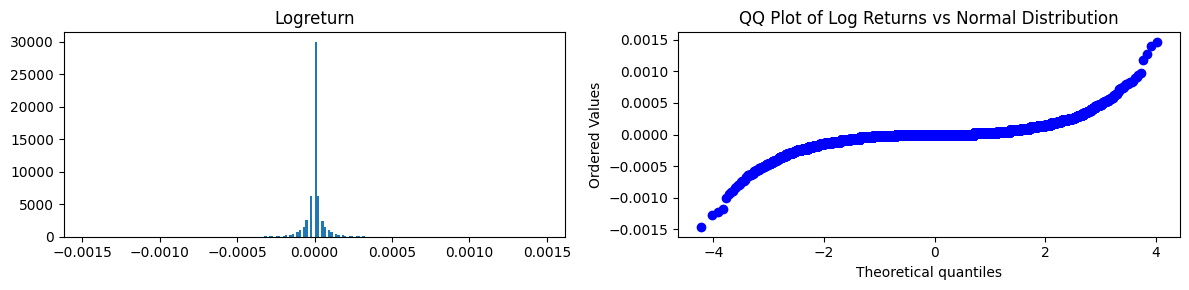

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(data['logret'],bins=200)
axes[0].set_title("Logreturn")

stats.probplot(data['logret'], dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot of Log Returns vs Normal Distribution')
plt.tight_layout()
plt.show()


## **Part III -** No Noise modelling

Let's assume the data has no microstructure (ie. no noise modelisation), and compute:
- realized variance
- spot volatility

We first to resample the prices, and to have the prices on a given grid of time. To do it we aggregate data using Vwap prices.

In [13]:
def vwap(df):
    '''
    Compute Vwap price
    '''
    vol = df['AskVolume'] + df['BidVolume']
    num = df['Ask'] * df['AskVolume'] + df['Bid'] * df['BidVolume']
    tot_vol = vol.sum()
    if tot_vol == 0:
        return np.nan   # no volume in this bin
    return num.sum() / tot_vol
    
def resample(data, T):
    """
    Resample DataFrame on calendar time with VWAP and previous-tick interpolation.

    data : pd.DataFrame with columns ['Time','Bid','BidVolume','Ask','AskVolume']
    T    : sampling period in seconds (int)
    """
    data = data.copy()
    data['Time'] = pd.to_datetime(data['Time'], unit='s')
    resampled = (
        data
        .set_index('Time')
        .resample(f'{T}s')
        .apply(vwap)
    )
    # Replace 0 or NaN by previous value (previous-tick interpolation)
    resampled = resampled.replace(0, np.nan).ffill()
    return resampled.dropna()

### **III a)** Realized Variance

Computation of Realized variance for different sampling periods, we show that without noise modelling, the realized variance diverge to infinity while the sampling period is shrinking

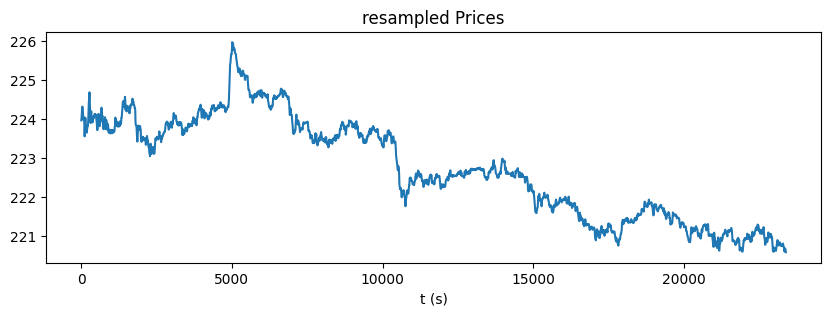

In [14]:
#resample prices
resampled_prices = (
    pd.DataFrame(resample(data,10))
    #.assign(Time = lambda df : df.index.strftime('%H:%M:%S'))
    .reset_index()
    .assign(Time = lambda df : df.index * 10)
    .rename(columns = {0:'mid'})
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(resampled_prices['Time'],resampled_prices['mid'])
ax.set_title('resampled Prices')
ax.set_xlabel('t (s)')
plt.show()

In [21]:
# compute RV
def get_RV(data,T):
    '''
    Compute Realized variance depending on sampling frequency
        data (pd.DataFrame) - price data
        T (int) - sampling period in second
    '''
    resampled_prices = resample(data,T)
    logret = np.log(resampled_prices).diff()
    RV = (logret**2).sum()
    return RV*100

RV_res = pd.read_excel('res\RV_res.xlsx',index_col=0)

#RV_res = []
#for i in range(1, 10, 1):
#    RV_res.append({'T_Sampling': i, 'RV': get_RV(data, i)})
#for i in range(10, 600, 10):
#    RV_res.append({'T_Sampling': i, 'RV': get_RV(data, i)})
#RV_res = pd.DataFrame(RV_res)

<>:13: SyntaxWarning: invalid escape sequence '\R'
<>:13: SyntaxWarning: invalid escape sequence '\R'
/var/folders/mq/vjflf4v17wv_rvtlxmrx4rrc0000gn/T/ipykernel_2472/2800253563.py:13: SyntaxWarning: invalid escape sequence '\R'
  RV_res = pd.read_excel('res\RV_res.xlsx',index_col=0)


FileNotFoundError: [Errno 2] No such file or directory: 'res\\RV_res.xlsx'

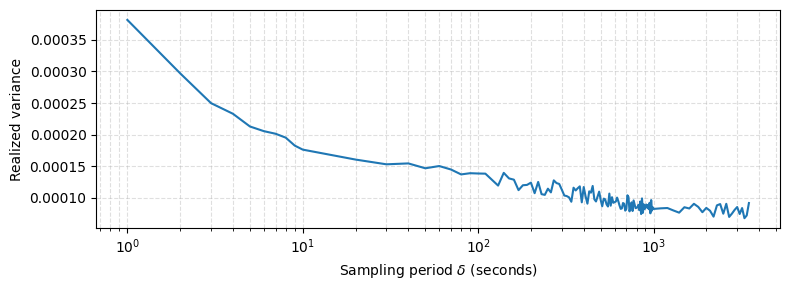

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.semilogx(
    RV_res["T_Sampling"],
    RV_res["RV"]
)

ax.set_xlabel("Sampling period $\delta$ (seconds)")
ax.set_ylabel("Realized variance")

ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.tick_params(axis="both")

plt.tight_layout()

plt.savefig(
    "signature_plot_rv_amzn_20120621.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### **III b)** Spot Volatility

We can compute it using two method:
- moving average method
- kernel estimator (reputed to have a be a better estimator)

We differenciate two cases:
1. Computation of the window size in term of number of orders
2. Computation of the window size after resampling to 1s prices 

In [ ]:
def get_vol(data,window_size=50,method='kernel'):
    '''
    Compute spot volatility, 
    data (pd.DataFrame) - price data
    method (string) - method to estimate
    window_size (int) - number of observation to estimate
    '''
    if method == 'MA':
        vol = (
            data['logret'].rolling(window_size)
            .apply(lambda df : (df**2).sum())
            .dropna()
            /window_size
        )
        
    elif method == 'kernel':
        bandwidth = window_size / 6  
        vol = (
            data['logret']
            .rolling(window_size, min_periods=window_size)
            .apply(
                lambda x: (
                    norm.pdf(
                        (x.index.values - x.index.values[len(x)//2]) / bandwidth
                    ) * (x.values**2)
                ).sum()
                /window_size
            )
        )
    return vol*100

#### **i)**  Use of number of order to compute the windows :

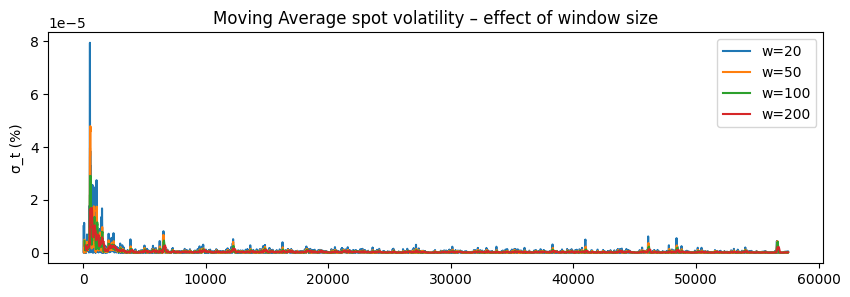

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [20, 50, 100, 200]:
    vol = get_vol(data, window_size=w, method='MA')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Moving Average spot volatility – effect of window size')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

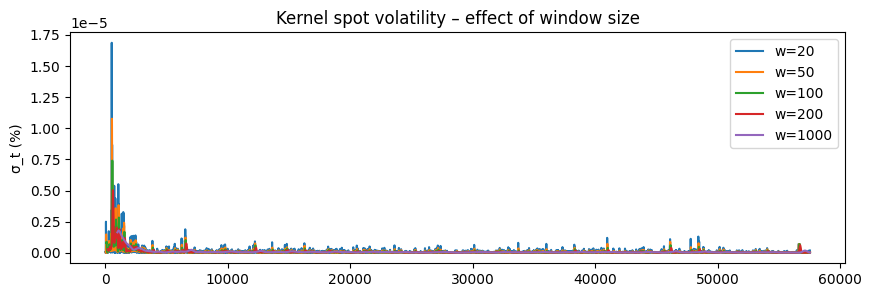

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [20, 50, 100, 200, 1000]:
    vol = get_vol(data, window_size=w, method='kernel')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Kernel spot volatility – effect of window size')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

Text(0.5, 0, 'time')

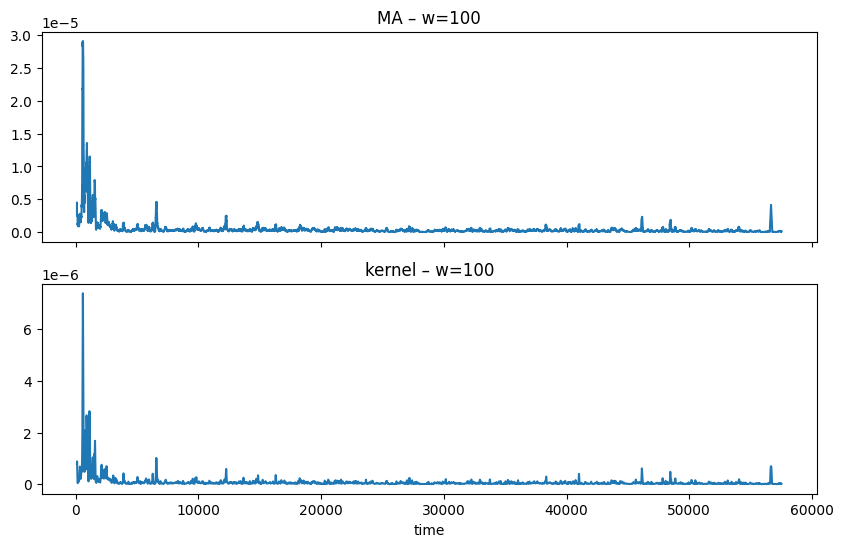

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

window_size = 100

for method, ax in zip(['MA', 'kernel'], axes):
    vol = get_vol(data, window_size=window_size, method=method)
    ax.plot(vol.index, vol)
    ax.set_title(f'{method} – w={window_size}')

axes[-1].set_xlabel('time')

#### **ii)** Use of time to compute the windows :

In [ ]:
sampled_prices = resample(data,1)

sampled_logret = (
    pd.DataFrame(sampled_prices)
        .reset_index()
        .rename(columns={0:'mid'})
        .assign(logret=lambda df : (np.log(df['mid'])**2).diff())
        .dropna()
)

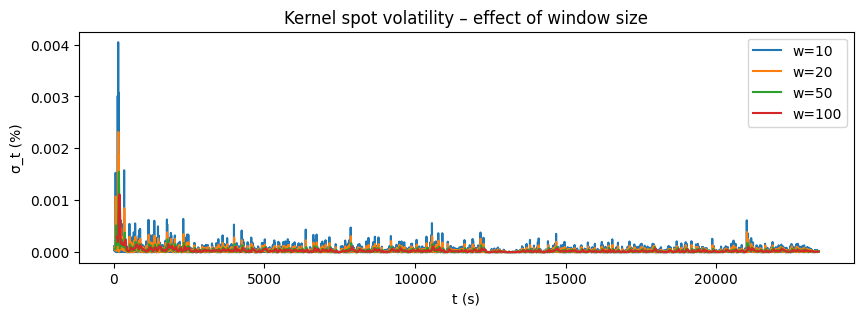

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [10, 20, 50, 100]:
    vol = get_vol(sampled_logret, window_size=w, method='kernel')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Kernel spot volatility – effect of window size')
ax.set_xlabel('t (s)')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

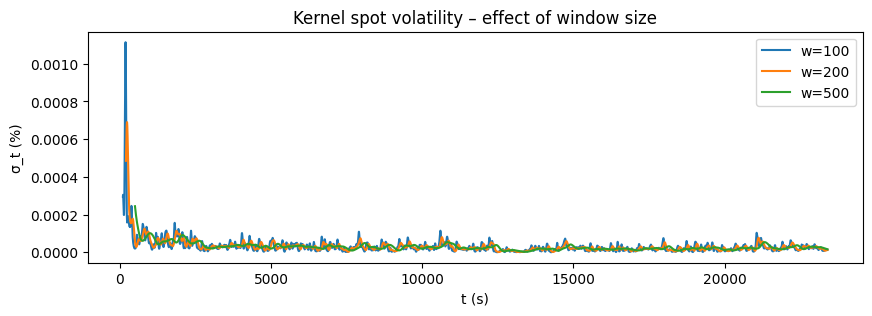

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [100, 200, 500]:
    vol = get_vol(sampled_logret, window_size=w, method='kernel')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('Kernel spot volatility – effect of window size')
ax.set_xlabel('t (s)')
ax.set_ylabel('σ_t (%)')
ax.legend()
plt.show()

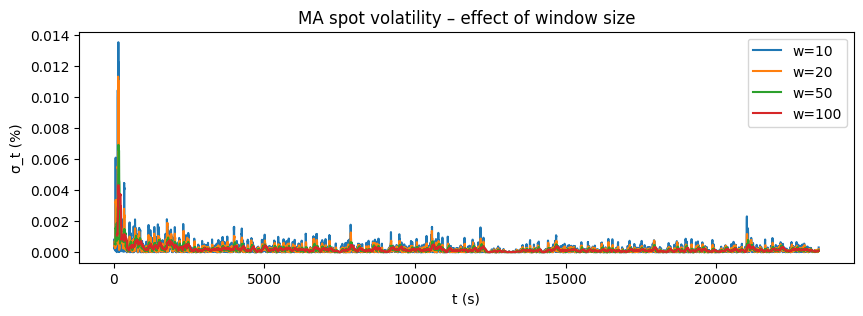

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

for w in [10, 20, 50, 100]:
    vol = get_vol(sampled_logret, window_size=w, method='MA')
    ax.plot(vol.index, vol, label=f'w={w}')

ax.set_title('MA spot volatility – effect of window size')
ax.set_ylabel('σ_t (%)')
ax.set_xlabel('t (s)')
ax.legend()
plt.show()

## **Part IV-** Noise Modelling

We first place ourself in the following model : $Y = X + \eta *\epsilon, \epsilon \sim \mathcal{N}(0,1)$.
1. Estimate $\eta$ using the $\frac{\widehat{RV_n}}{n}$ estimator
2. Estimate $\eta$ using the lag-1 autocovariance function

### **IV. a)** $\frac{\widehat{RV_n}}{n}$ estimator

In [ ]:
eta_res = []

#for i in [i/2 for i in range(1, 20, 1)] + [i for i in range(10, 200, 10)]:
#    n = 24000/i
#    eta_est = np.sqrt(get_RV(data, i)/n/2)
#    eta_res.append({'T_Sampling': i, 'eta_est': eta_est})

#pd.DataFrame(eta_res).to_excel('res\eta_res_1.xlsx')
eta_res = pd.read_excel('res\eta_res_1.xlsx',index_col = 0)

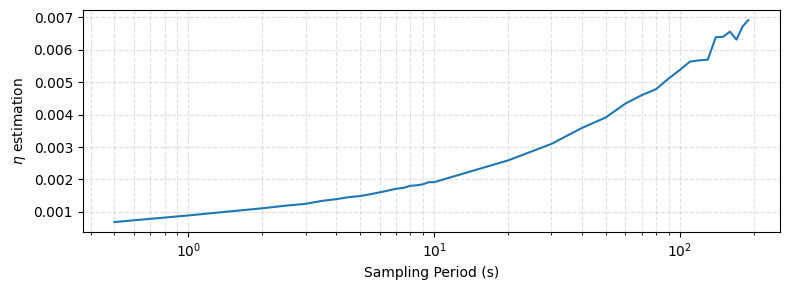

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(eta_res['T_Sampling'],eta_res['eta_est'])
ax.set_xlabel('Sampling Period (s)')
ax.set_ylabel(r'$\eta$ estimation')
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.tick_params(axis="both")
#ax.set_title(r"$\eta$ estimation Vs Sampling Period")
plt.tight_layout()


plt.savefig(
    "eta_estimation_RV_20120621.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **IV.b)** lag-1 autocovariance function

In [ ]:
def lag1_autocov(data,T):
    """
    Compute sample lag-1 autocovariance
        data (pd.DataFrame) - price data
        T (int) - sampling period in second
    """
    x = resample(data,T)
    x = np.log(x)
    x = x.diff().dropna()
    mean = x.mean()
    return ((x.shift(0) - mean) * (x.shift(-1) - mean)).mean()

def rolling_autocov(x, window=200):
    """
    Rolling lag-1 autocovariance of series x.
    """
    x = pd.Series(x).dropna()
    mean = x.rolling(window).mean()

    cov = ((x.shift(0) - mean) * (x.shift(1) - mean)).rolling(window).mean()
    return cov



In [ ]:
#eta_res_gamma1 = []

#for i in [i/4 for i in range(1, 40, 1)] :
#    n = 24000/i
#    gamma1 = lag1_autocov(data, i)
#    eta_est = 0
#    if gamma1<0:
#        eta_est = np.sqrt(-1*lag1_autocov(data, i))
#    eta_res_gamma1.append({'T_Sampling': i, 'eta_est': eta_est})

#pd.DataFrame(eta_res_gamma1).to_excel('res\eta_res_gamma.xlsx')


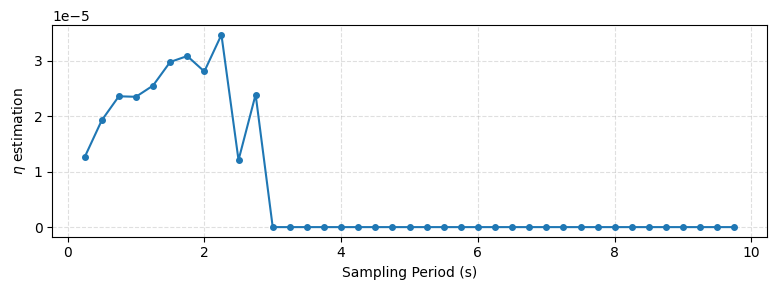

In [ ]:
eta_res_gamma = pd.read_excel('res\eta_res_gamma.xlsx',index_col = 0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(eta_res_gamma['T_Sampling'],eta_res_gamma['eta_est'],
       marker="o",markersize=4)
ax.set_xlabel('Sampling Period (s)')
ax.set_ylabel(r'$\eta$ estimation')
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.tick_params(axis="both")
#ax.set_title(r"$\eta$ estimation Vs Sampling Period")
plt.tight_layout()
plt.show()

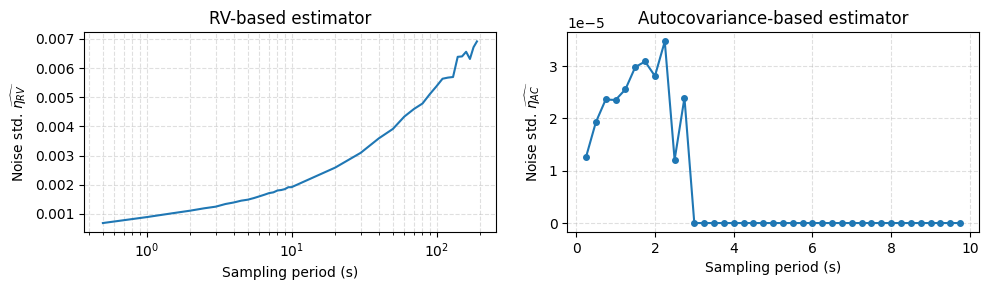

In [ ]:
fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(10, 3)
)

# --- Left: RV-based estimator (log x-scale) ---
axes[0].semilogx(
    eta_res['T_Sampling'],
    eta_res['eta_est']
)
axes[0].set_xlabel('Sampling period (s)')
axes[0].set_ylabel(r'Noise std. $\widehat{\eta_{RV}}$')
axes[0].set_title('RV-based estimator')
axes[0].grid(True, which="both", linestyle="--", alpha=0.4)
axes[0].tick_params(axis="both")

# --- Right: Gamma / alternative estimator (linear scale) ---
axes[1].plot(
    eta_res_gamma['T_Sampling'],
    eta_res_gamma['eta_est'],
    marker="o",
    markersize=4,
)
axes[1].set_xlabel('Sampling period (s)')
axes[1].set_ylabel(r'Noise std. $\widehat{\eta_{AC}}$')
axes[1].set_title('Autocovariance-based estimator')
axes[1].grid(True, which="both", linestyle="--", alpha=0.4)
axes[1].tick_params(axis="both")

# --- Global layout ---
plt.tight_layout()
plt.savefig(
    "eta_estimation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### **IV. c)** Autocovariance plot

For a sampling period of 1second.

In [ ]:
sampled_prices = resample(data,1)

sampled_data = (
    pd.DataFrame(sampled_prices)
        .reset_index()
        .rename(columns={0:'mid'})
        .assign(logprice=lambda df : (np.log(df['mid'])))
        .assign(logret=lambda df : np.log(df['mid']).diff())
        .dropna()
)

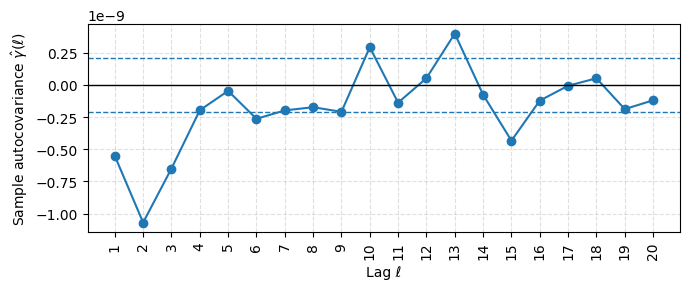

In [ ]:
X = sampled_data['logprice']
x = X.dropna().astype(float).values
r = np.diff(x)

# Ljung–Box
T = len(r)
gamma0 = np.mean(r**2)  # variance
z = norm.ppf(0.975)     # 95% level
conf_band = z * gamma0 / np.sqrt(T)

Lmax = 20
gamma = [np.mean(r[:-ell] * r[ell:]) for ell in range(1, Lmax+1)]

plt.figure(figsize=(7, 3))
plt.plot(range(1, Lmax+1), gamma, marker='o')
plt.axhline(0, linewidth=1, color="black")
plt.axhline(+conf_band, linestyle="--", linewidth=1)
plt.axhline(-conf_band, linestyle="--", linewidth=1)

plt.xlabel("Lag ℓ")
plt.ylabel(r"Sample autocovariance $\hat{\gamma}(\ell)$")

plt.xticks(range(1, Lmax+1), rotation=90)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(
    "autocovariance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## **Part V-** VaR Computation

### **V. a)** Robust estimation of the Realized Variance

In [ ]:
def get_robust_rv(X: pd.Series, L=None):
    """
    Subsampling noise-robust estimator of RealizedVariance.
    """
    x = X.dropna().values
    n = len(x)   # number of returns
    
    r_all = np.diff(x)
    RV_all = np.sum(r_all**2)
    
    if L == None:
        L = int(round(n**(2/3)))
        L = max(2, min(L, n // 2))
        
    RV_sub = []
    m_sub = []
    for ell in range(L):
        x_ell = x[ell::L]
        if len(x_ell) < 2:
            continue
        r_ell = np.diff(x_ell)
        RV_ell = np.sum(r_ell**2)   
        RV_sub.append(RV_ell)
        m_sub.append(len(r_ell))    
    
    RV_avg = np.mean(RV_sub)
    m_bar = np.mean(m_sub)
    return RV_avg - (m_bar / n) * RV_all

### **V. b)** Test for parametrized VaR

{'n_h': 77, 'sigma_h': 0.001367917232951334, 't_test_mean0_p': 0.3013365528974805, 'JB_normality_p': 1.2851007444405012e-35, 'LjungBox_U_p(lag10)': 0.4498044316806904, 'LjungBox_U2_p(lag10)': 0.9707117835417232, 'skew': 1.143816771067848, 'kurtosis_excess': 9.696908764013745}


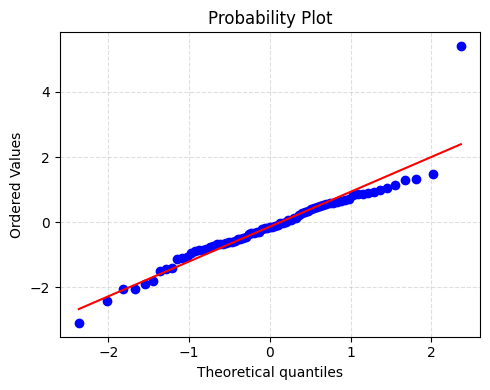

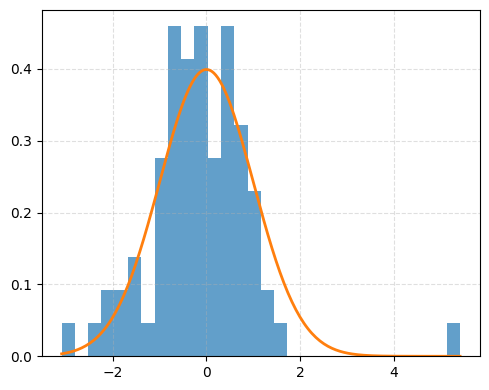

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# --- Inputs ---
h_seconds = 300   # 5 minutes

# Clean series
X_sec = X.dropna().astype(float)

# Session length (seconds)
T_seconds = float(X_sec.index.max() - X_sec.index.min())

# Horizon vol from robust daily RV
RV_S = get_robust_rv(X_sec)
sigma_h = np.sqrt((h_seconds / T_seconds) * RV_S)

# Non-overlapping h-returns + standardization
x_block = X_sec.values[::h_seconds]   # assumes 1-second regular grid
r_h = np.diff(x_block)
U = r_h / sigma_h

# Tests
p_mean0 = stats.ttest_1samp(U, 0.0).pvalue
jb_stat, jb_p, skew, kurt_excess = jarque_bera(U)
lb_U  = acorr_ljungbox(U,    lags=[10], return_df=True)["lb_pvalue"].iloc[0]
lb_U2 = acorr_ljungbox(U**2, lags=[10], return_df=True)["lb_pvalue"].iloc[0]

print({
    "n_h": len(U),
    "sigma_h": float(sigma_h),
    "t_test_mean0_p": float(p_mean0),
    "JB_normality_p": float(jb_p),
    "LjungBox_U_p(lag10)": float(lb_U),
    "LjungBox_U2_p(lag10)": float(lb_U2),
    "skew": float(skew),
    "kurtosis_excess": float(kurt_excess),
})

# QQ plot
plt.figure(figsize=(5, 4))
stats.probplot(U, dist="norm", plot=plt)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Histogram vs N(0,1)
plt.figure(figsize=(5, 4))
plt.hist(U, bins=30, density=True, alpha=0.7)
xx = np.linspace(U.min(), U.max(), 200)
plt.plot(xx, stats.norm.pdf(xx, 0, 1), linewidth=2)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Backtest**

Since only one day is available, we cannot perform a proper out-of-sample VaR backtest.

However, we can approximate a pseudo-backtest by splitting the day into intraday windows (e.g., 30 min) and counting VaR exceptions inside the day.

- We clearly see that the parametric VaR is too conservative and overstating the risk

In [ ]:
# log-price series at 1-second grid (pd.Series)
logp_1s = X.dropna().astype(float)

alpha = 0.05
z = norm.ppf(alpha)

h = 60                 # horizon in seconds for VaR returns (set 1 for 1s VaR, 300 for 5min, etc.)
train_len = 2*3600     # 2 hours training
test_len  = 30*60      # 60 min testing
step_len  = 30*60      # roll every 30 min

Res = []
fold = 0

T = len(logp_1s)

for start in range(0, T - train_len - test_len + 1, step_len):
    train_slice = logp_1s.iloc[start : start + train_len]
    test_slice  = logp_1s.iloc[start + train_len : start + train_len + test_len]

    # h-returns for backtesting (non-overlapping)
    train_h = train_slice.iloc[::h].diff().dropna().values
    test_h  = test_slice.iloc[::h].diff().dropna().values
    
    # --- Non-parametric VaR (empirical) ---
    var_np = np.quantile(train_h, alpha)
    exc_np = (test_h < var_np).mean()

    # Parametric VaR using naive RV on 1-second prices ---
    r_1s = train_slice.diff().dropna().values
    RV_all = np.sum(r_1s**2)
    n_1s = len(r_1s)

    sigma_h_naive = np.sqrt(RV_all / n_1s * h)   # scale to horizon h
    var_par_naive = sigma_h_naive * z
    exc_par_naive = (test_h < var_par_naive).mean()

    # Robust RV on 1-second prices over train block (your function)
    RV_robust = get_robust_rv(train_slice, L=None)     # variance over the whole train block on 1s grid
    n_1s = len(train_slice) - 1

    # Convert to sigma for h-returns: sigma_h^2 ≈ h * (RV_robust / n_1s)
    sigma_robust = np.sqrt(max(RV_robust, 0.0) / n_1s * h)
    var_par_robust = sigma_robust * z
    exc_par_robust = (test_h < var_par_robust).mean()

    Res.append({"fold": fold, "exc_np": exc_np, "exc_par_naive": exc_par_naive, "exc_par_robust": exc_par_robust})
    fold += 1

Res = pd.DataFrame(Res)

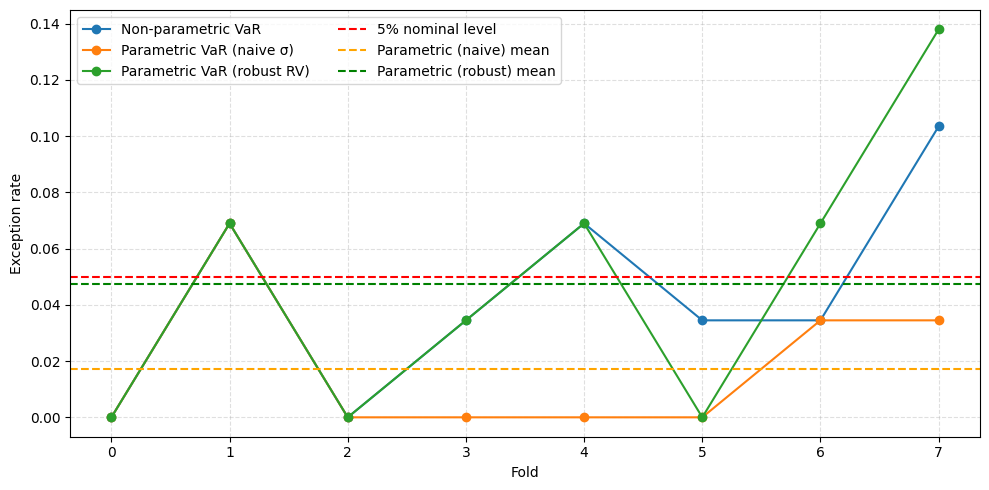

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(Res['fold'], Res['exc_np'], marker='o', label='Non-parametric VaR')
ax.plot(Res['fold'], Res['exc_par_naive'], marker='o', label='Parametric VaR (naive σ)')
ax.plot(Res['fold'], Res['exc_par_robust'], marker='o', label='Parametric VaR (robust RV)')

ax.axhline(0.05, linestyle='--', color='red', label='5% nominal level')
ax.axhline(Res['exc_par_naive'].mean(), linestyle='--', color='orange', label='Parametric (naive) mean')
ax.axhline(Res['exc_par_robust'].mean(), linestyle='--', color='green', label='Parametric (robust) mean')

ax.set_xlabel('Fold')
ax.set_ylabel('Exception rate')
#ax.set_title('Intraday VaR: Pseudo-backtest (one trading day)')
ax.legend(ncol=2)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(
    "backtest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
